In [4]:
!pip install arch
# -r /Users/marysia/Desktop/applied/ml_project/requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import glob
import os

In [7]:
df = pd.read_csv("/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean/spy_clean.csv", index_col=0, parse_dates=True)
df.sort_index(ascending=True, inplace=True)
returns_df = df.drop(columns=['Open', 'High', 'Low']).pct_change().apply(lambda x: np.log(1 + x))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
returns_df.head()

,Close,Volume
Date,,
2005-02-25,NaN,NaN
2005-02-28,-0.006734,0.126552
2005-03-01,0.005126,-0.378042
2005-03-02,-0.000474,0.300282
2005-03-03,0.000379,-0.033740


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

warnings.filterwarnings("ignore")

# 1. reading SPY data
# Date,Open,High,Low,Close,Volume
spy_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean/spy_clean.csv'
df_spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True)
df_spy.sort_index(ascending=True, inplace=True)

df_spy['Returns'] = np.log(df_spy['Close'] / df_spy['Close'].shift(1))
df_spy.dropna(inplace=True)

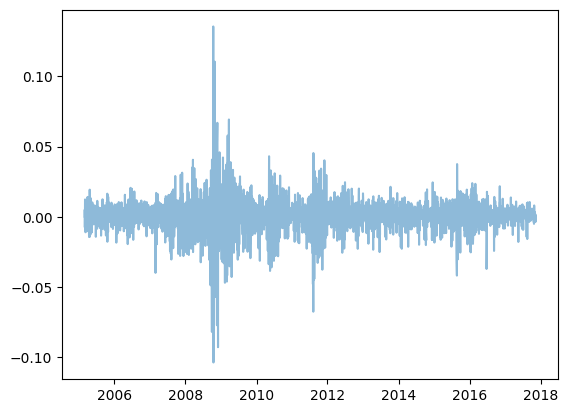

In [12]:
plt.plot(df_spy.index, df_spy['Returns'], alpha=0.5)


Text(0.5, 0, 'h')

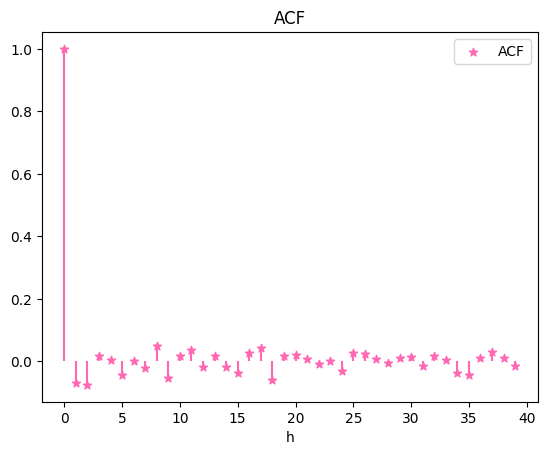

In [13]:
def sampleACVF(X, h):
    n = len(X)
    x_mean = np.mean(X)
    return 1/n*sum((X[i]-x_mean)*(X[i+abs(h)]-x_mean) for i in range(1,n-abs(h)))
def sampleACF(X, h):
    return sampleACVF(X, h)/sampleACVF(X, 0)

hs = np.arange(40)
acc = [sampleACF(np.array(df_spy['Returns']), h) for h in hs]
plt.vlines(x=hs, ymin=0, ymax=acc, color = 'hotpink')
plt.scatter(hs, acc, marker = '*', color = 'hotpink', label = 'ACF')
plt.title('ACF'); plt.legend()
plt.xlabel('h')

Text(0.5, 0, 'h')

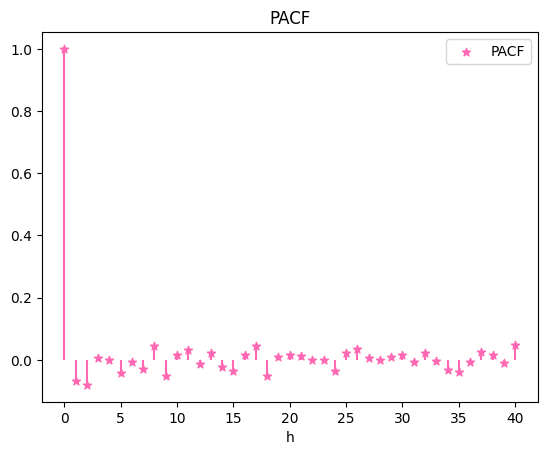

In [14]:
from statsmodels.tsa.stattools import pacf, adfuller, acf
pacf_, confint = pacf(np.array(df_spy['Returns']), nlags=40, method='ld', alpha=0.05)
# c1, c2 = np.array([p[0] for p in confint]), np.array([p[1] for p in confint])
# plt.fill_between(hs1, c1, c2, color = 'darkseagreen')
hs1 = np.arange(41)
plt.vlines(x=hs1, ymin=0, ymax=pacf_, color = 'hotpink')
plt.scatter(hs1, pacf_, marker = '*', color = 'hotpink', label = 'PACF')
plt.title('PACF'); plt.legend()
plt.xlabel('h')

In [15]:
data = df_spy['Returns'].values

df = pd.DataFrame()
ps = []
qs = []
BIC = []
AIC = []
HQIC = []

max_p = 5
max_q = 5

for p in range(0, max_p):
    for q in range(0, max_q):
        model = ARIMA(data, order=(p, 0, q))
        model_fit = model.fit()
        ps.append(p)
        qs.append(q)
        AIC.append(model_fit.aic)
        BIC.append(model_fit.bic)
        HQIC.append(model_fit.hqic)

df['p']    = ps
df['q']    = qs
df['AIC']  = AIC
df['BIC']  = BIC
df['HQIC'] = HQIC

In [16]:
df.sort_values(by='AIC').head()

,p,q,AIC,BIC,HQIC
19,3,4,-20148.781009,-20093.825093,-20129.113654
9,1,4,-20144.688293,-20101.944803,-20129.391462
10,2,0,-20144.408184,-20119.983333,-20135.667138
2,0,2,-20144.018746,-20119.593894,-20135.277699
15,3,0,-20142.470152,-20111.939088,-20131.543845


In [17]:
df.sort_values(by='BIC').head()

,p,q,AIC,BIC,HQIC
10,2,0,-20144.408184,-20119.983333,-20135.667138
2,0,2,-20144.018746,-20119.593894,-20135.277699
6,1,1,-20136.381907,-20111.957055,-20127.640860
15,3,0,-20142.470152,-20111.939088,-20131.543845
11,2,1,-20142.467797,-20111.936732,-20131.541489


In [18]:
df.sort_values(by='HQIC').head()

,p,q,AIC,BIC,HQIC
10,2,0,-20144.408184,-20119.983333,-20135.667138
2,0,2,-20144.018746,-20119.593894,-20135.277699
15,3,0,-20142.470152,-20111.939088,-20131.543845
11,2,1,-20142.467797,-20111.936732,-20131.541489
3,0,3,-20142.129468,-20111.598403,-20131.203160


In [19]:
# 2. stationarity test (ADF Test)
def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    return result[1] < 0.05

print("--- SPY Stationarity Test ---")
is_stationary = check_stationarity(df_spy['Returns'])
print(f"Stationary? {is_stationary}\n")

--- SPY Stationarity Test ---
ADF Statistic: -14.1793
p-value: 0.0000
Stationary? True



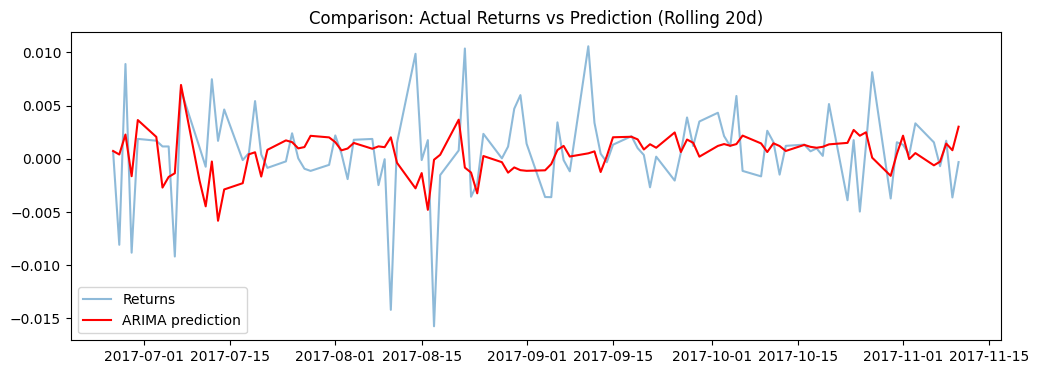

In [ ]:
window = 20
results = []

for i in range(len(df_spy) - window):
    train_window = df_spy['Returns'].iloc[i:i+window]
    # ARIMA(1,0,1) - d=0 logreturns are already stationary
    model = ARIMA(train_window, order=(2, 0, 0)).fit()
    forecast = model.forecast(steps=1).values[0]
    results.append(forecast)

# results DF (omit first 20 days)
df_eval = df_spy.iloc[window:].copy()
df_eval['Pred_Return'] = results

# comparison plot - last 100 days for readability
plt.figure(figsize=(12, 4))
plt.plot(df_eval['Returns'].iloc[-100:], label='Returns', alpha=0.5)
plt.plot(df_eval['Pred_Return'].iloc[-100:], label='ARIMA prediction', color='red')
plt.title('Comparison: Actual Returns vs Prediction (Rolling 20d)')
plt.legend()
plt.show()

In [ ]:
# SPY test
model_test = ARIMA(df_spy['Returns'].tail(100), order=(2, 0, 0)).fit()
print(model_test.summary())

                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  100
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 409.318
Date:                Tue, 09 Jun 2026   AIC                           -810.636
Time:                        20:35:42   BIC                           -800.216
Sample:                    06-26-2017   HQIC                          -806.419
                         - 11-10-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      1.698      0.090      -0.000       0.001
ar.L1         -0.1670      0.111     -1.506      0.132      -0.384       0.050
ar.L2         -0.0956      0.107     -0.896      0.3

In [ ]:
window = 20
results = []

for i in range(len(df_spy) - window):
    train_window = df_spy['Returns'].iloc[i:i+window]
    # ARIMA(1,0,1) - d=0 logreturns are already stationary
    model = ARIMA(train_window, order=(0, 0, 2)).fit()
    forecast = model.forecast(steps=1).values[0]
    results.append(forecast)

# results DF (omit first 20 days)
df_eval = df_spy.iloc[window:].copy()
df_eval['Pred_Return_02'] = results

In [23]:
from sklearn.metrics import accuracy_score

df_eval['Actual_Dir'] = np.where(df_eval['Returns'] > 0, 1, 0)
df_eval['Pred_Dir'] = np.where(df_eval['Pred_Return'] > 0, 1, 0)
# df_eval['Pred_Return_02'] = np.where(df_eval['Pred_Return_02'] > 0, 1, 0)

acc = accuracy_score(df_eval['Actual_Dir'], df_eval['Pred_Dir'])
# acc_02 = accuracy_score(df_eval['Actual_Dir'], df_eval['Pred_Return_02'])

print(f"Accuracy (Up/down?): {acc:.2%}")
# print(f"Accuracy (Up/down?) - ARIMA(0,0,2): {acc_02:.2%}")

KeyError: 'Pred_Return'

In [ ]:
# train['sigma'] = model.conditional_volatility
df_eval

,Open,High,Low,Close,Volume,Returns,Pred_Return,Actual_Dir,Pred_Dir
Date,,,,,,,,,
2005-03-28,102.29,102.75,102.19,102.19,53885043.0,0.000685,-0.001780,1,0
2005-03-29,102.05,102.71,101.27,101.51,83849903.0,-0.006677,-0.001297,0,0
2005-03-30,101.85,102.98,101.72,102.96,72199510.0,0.014183,-0.001339,1,0
2005-03-31,102.97,103.19,102.68,102.77,74669192.0,-0.001847,-0.005468,0,0
2005-04-01,103.34,103.66,101.85,102.30,111800673.0,-0.004584,-0.000763,0,0
...,...,...,...,...,...,...,...,...,...
2017-11-06,258.30,259.00,258.22,258.85,49529148.0,0.001546,-0.000615,1,0
2017-11-07,258.97,259.35,258.11,258.67,57218448.0,-0.000696,-0.000269,0,0
2017-11-08,258.47,259.22,258.15,259.11,50277699.0,0.001700,0.001431,1,1


In [ ]:
def garman_klass(df):
    log_hl = np.log(df['High'] / df['Low'])
    log_co = np.log(df['Close'] / df['Open'])
    variance = 0.5*(log_hl ** 2) - (2 * np.log(2) - 1) * (log_co ** 2)
    return np.sqrt(variance)*100
GK = garman_klass(df_eval)

/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_64502/2508101393.py:7: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_64502/2508101393.py:7: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_64502/2508101393.py:7: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off'

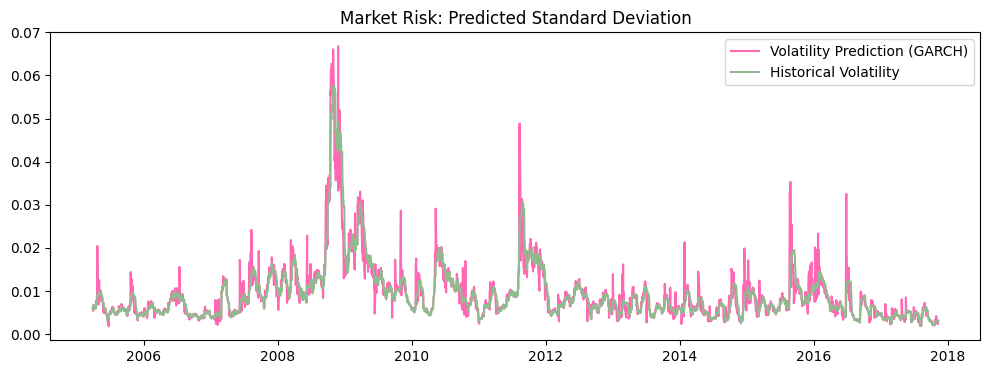

In [ ]:
# GARCH window 20
vols = []
vols2 = []
for i in range(len(df_spy) - window):
    train_window = df_spy['Returns'].iloc[i:i+window]
    # rescale=False, to keep units of returns
    garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
    v_forecast = np.sqrt(garch.forecast(horizon=1).variance.values[-1][0])
    vols.append(v_forecast)
    vols2.append(np.std(train_window))

df_eval['Pred_Vol'] = vols
df_eval['Pred_Vol2'] = vols2

# Volatility plot
plt.figure(figsize=(12, 4))
plt.plot(df_eval['Pred_Vol'], color='hotpink', label='Volatility Prediction (GARCH)')
plt.plot(df_eval['Pred_Vol2'], color='darkseagreen', label='Historical Volatility')
# plt.plot(GK, color='green', label='Garman-Klass Volatility')
plt.title('Market Risk: Predicted Standard Deviation')
plt.legend()
plt.show()

Calculating forecasts (Rolling Window 20d)...


/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_64502/2332272609.py:35: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_64502/2332272609.py:35: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_64502/2332272609.py:35: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='o

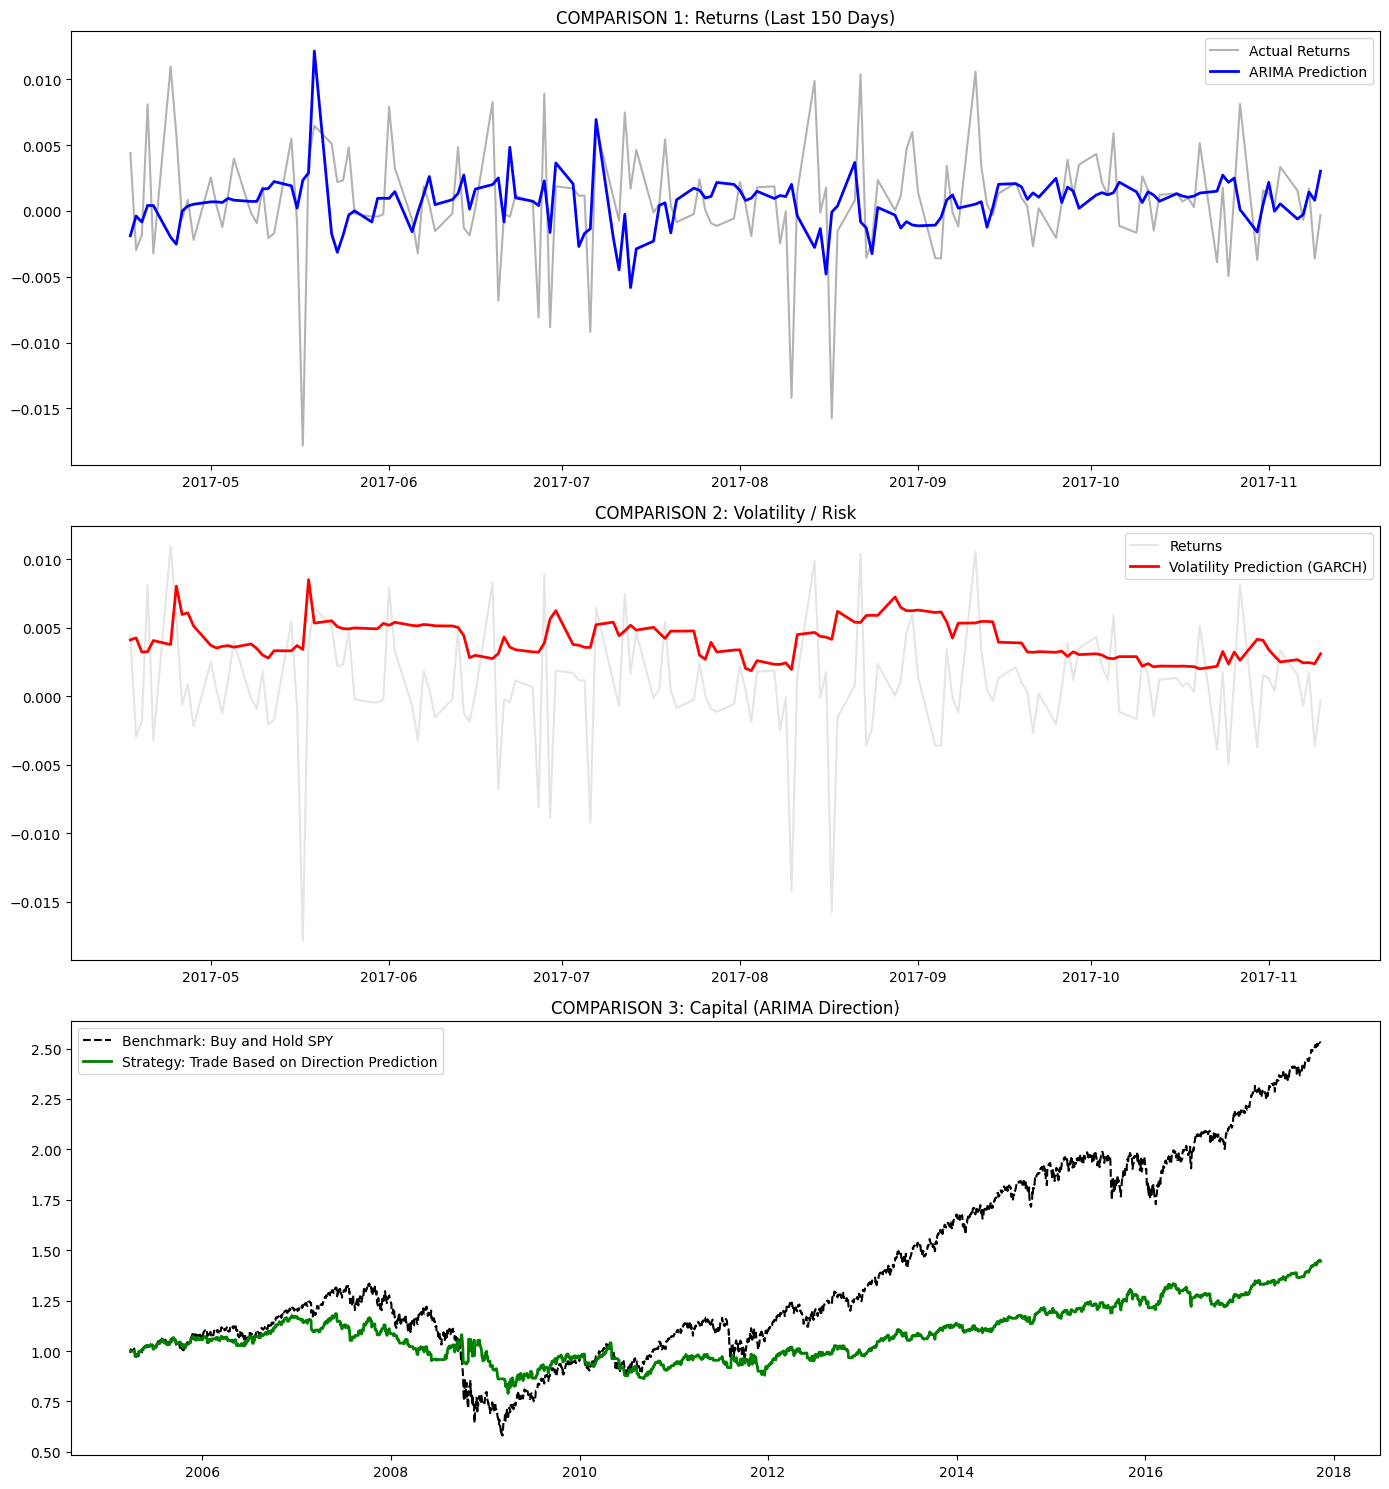

------------------------------
SUMMARY OF SP500 MODEL:
Direction Accuracy: 51.02%
------------------------------
Classification Report:
              precision    recall  f1-score   support

        DOWN       0.45      0.39      0.42      1492
          UP       0.55      0.61      0.58      1803

    accuracy                           0.51      3295
   macro avg       0.50      0.50      0.50      3295
weighted avg       0.50      0.51      0.51      3295



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import accuracy_score, classification_report

# 1. data preparation
spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True)
spy.sort_index(ascending=True, inplace=True)
spy['Returns'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy.dropna(inplace=True)

# Window settings
window = 20
pred_returns = []
pred_vols = []

print("Calculating forecasts (Rolling Window 20d)...")

for i in range(len(spy) - window):
    train_window = spy['Returns'].iloc[i:i+window]
    
    # --- MODEL 1: ARIMA (Returns) ---
    # params: (2,0,0) 
    try:
        arima = ARIMA(train_window, order=(2, 0, 0)).fit()
        f_ret = arima.forecast(steps=1).values[0]
    except: f_ret = 0
        
    # --- MODEL 2: GARCH (Volatility) ---
    # params: (1,1) - standard model
    try:
        garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
        f_vol = np.sqrt(garch.forecast(horizon=1).variance.values[-1][0])
    except: f_vol = spy['Returns'].std()

    pred_returns.append(f_ret)
    pred_vols.append(f_vol)

# comparison DataFrame
df_comp = spy.iloc[window:].copy()
df_comp['Pred_Return'] = pred_returns
df_comp['Pred_Vol'] = pred_vols
df_comp['Actual_Dir'] = (df_comp['Returns'] > 0).astype(int)
df_comp['Pred_Dir'] = (df_comp['Pred_Return'] > 0).astype(int)
spy_cum = (1 + (np.exp(df_comp['Returns']) - 1)).cumprod()
# --- COMPARATIVE ANALYSIS ---

fig, axs = plt.subplots(3, 1, figsize=(14, 15))

# 1. Comparison of Returns (Regression)
axs[0].plot(df_comp['Returns'].tail(150), label='Actual Returns', color='black', alpha=0.3)
axs[0].plot(df_comp['Pred_Return'].tail(150), label='ARIMA Prediction', color='blue', linewidth=2)
axs[0].set_title('COMPARISON 1: Returns (Last 150 Days)')
axs[0].legend()

# 2. Comparison of Volatility (Risk)
axs[1].plot(df_comp.index[-150:], df_comp['Returns'].tail(150), color='gray', alpha=0.2, label='Returns')
axs[1].plot(df_comp['Pred_Vol'].tail(150), label='Volatility Prediction (GARCH)', color='red', linewidth=2)
axs[1].set_title('COMPARISON 2: Volatility / Risk')
axs[1].legend()

# 3. Cumulative Return (Portfolio Effectiveness)
spy_cum = (1 + (np.exp(df_comp['Returns']) - 1)).cumprod()
strat_cum = (1 + (df_comp['Pred_Dir'] * (np.exp(df_comp['Returns']) - 1))).cumprod()
axs[2].plot(spy_cum, label='Benchmark: Buy and Hold SPY', color='black', linestyle='--')
axs[2].plot(strat_cum, label='Strategy: Trade Based on Direction Prediction', color='green', linewidth=2)
axs[2].set_title('COMPARISON 3: Capital (ARIMA Direction)')
axs[2].legend()

plt.tight_layout()
plt.show()

# --- STATISTICAL SUMMARY ---
acc = accuracy_score(df_comp['Actual_Dir'], df_comp['Pred_Dir'])
print("-" * 30)
print(f"SUMMARY OF SP500 MODEL:")
print(f"Direction Accuracy: {acc:.2%}")
print("-" * 30)
print("Classification Report:")
print(classification_report(df_comp['Actual_Dir'], df_comp['Pred_Dir'], target_names=['DOWN', 'UP']))

Generuję zaawansowane cechy (ARIMA 20d, GARCH 60d)...


/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_64502/1746115086.py:40: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_64502/1746115086.py:40: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_64502/1746115086.py:40: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fi


Gotowy Feature Matrix dla modeli ML:
             Close  Dist_From_MA200  ARIMA_20d_Pred  GARCH_60d_Vol
Date                                                              
2017-11-06  258.85         0.073360       -0.000942       0.003416
2017-11-07  258.67         0.071850       -0.000329       0.003716
2017-11-08  259.11         0.072903        0.000815       0.003468
2017-11-09  258.17         0.068267        0.000388       0.002640
2017-11-10  258.09         0.067230        0.003171       0.003149


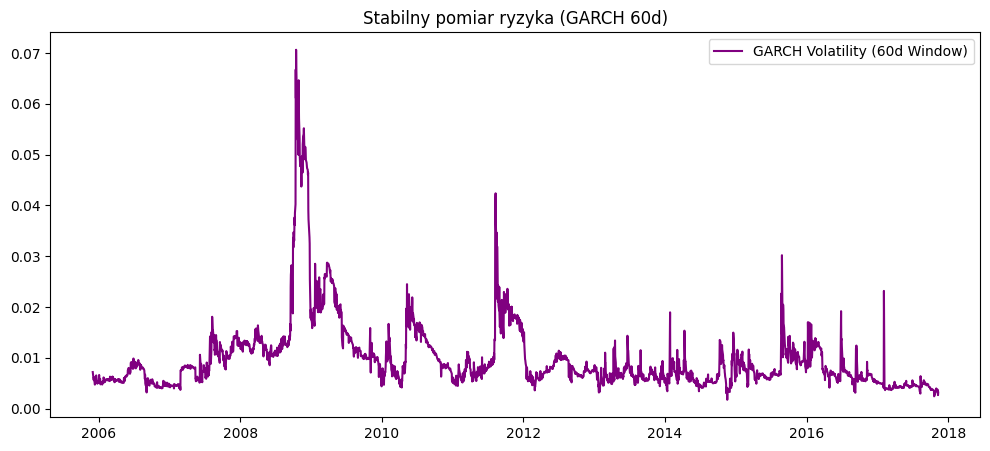

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

warnings.filterwarnings("ignore")

# 1. Przygotowanie danych bazowych
spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True)
spy.sort_index(ascending=True, inplace=True)
spy['Returns'] = np.log(spy['Close'] / spy['Close'].shift(1))

# 2. Wskaźniki Długoterminowe (Obliczane na całym szeregu - szybkie)
# Średnia krocząca 200 dni (Trend długoterminowy)
spy['MA200_Trend'] = spy['Close'].rolling(window=200).mean()
spy['Dist_From_MA200'] = (spy['Close'] - spy['MA200_Trend']) / spy['MA200_Trend']

# 3. Pętla Krocząca dla ARIMA (20d) i GARCH (60d)
# Zaczynamy od 200, żeby MA200 było już gotowe
start_idx = 200
arima_preds = []
garch_vols = []
dates = []

print("Generuję zaawansowane cechy (ARIMA 20d, GARCH 60d)...")

for i in range(start_idx, len(spy)):
    # --- KRÓTKIE OKNO (20d) dla ARIMA ---
    window_20 = spy['Returns'].iloc[i-20:i]
    try:
        model_arima = ARIMA(window_20, order=(1, 0, 1)).fit()
        pred_ret = model_arima.forecast(steps=1).values[0]
    except: pred_ret = 0
    
    # --- DŁUŻSZE OKNO (60d) dla GARCH ---
    # Zmienność potrzebuje więcej danych, by "zauważyć" trend strachu
    window_60 = spy['Returns'].iloc[i-60:i]
    try:
        model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
        pred_vol = np.sqrt(model_garch.forecast(horizon=1).variance.values[-1][0])
    except: pred_vol = spy['Returns'].iloc[:i].std()

    arima_preds.append(pred_ret)
    garch_vols.append(pred_vol)
    dates.append(spy.index[i])

# 4. Łączenie wszystkiego w jedną tabelę (Feature Matrix)
df_features = spy.loc[dates].copy()
df_features['ARIMA_20d_Pred'] = arima_preds
df_features['GARCH_60d_Vol'] = garch_vols

# Czyścimy NaN (z MA200)
df_features.dropna(inplace=True)

# 5. Podsumowanie i podgląd
print("\nGotowy Feature Matrix dla modeli ML:")
print(df_features[['Close', 'Dist_From_MA200', 'ARIMA_20d_Pred', 'GARCH_60d_Vol']].tail())

# Wizualizacja dla raportu: Porównanie zmienności 20d vs 60d (opcjonalnie)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df_features['GARCH_60d_Vol'], color='purple', label='GARCH Volatility (60d Window)')
plt.title('Stabilny pomiar ryzyka (GARCH 60d)')
plt.legend()
plt.show()

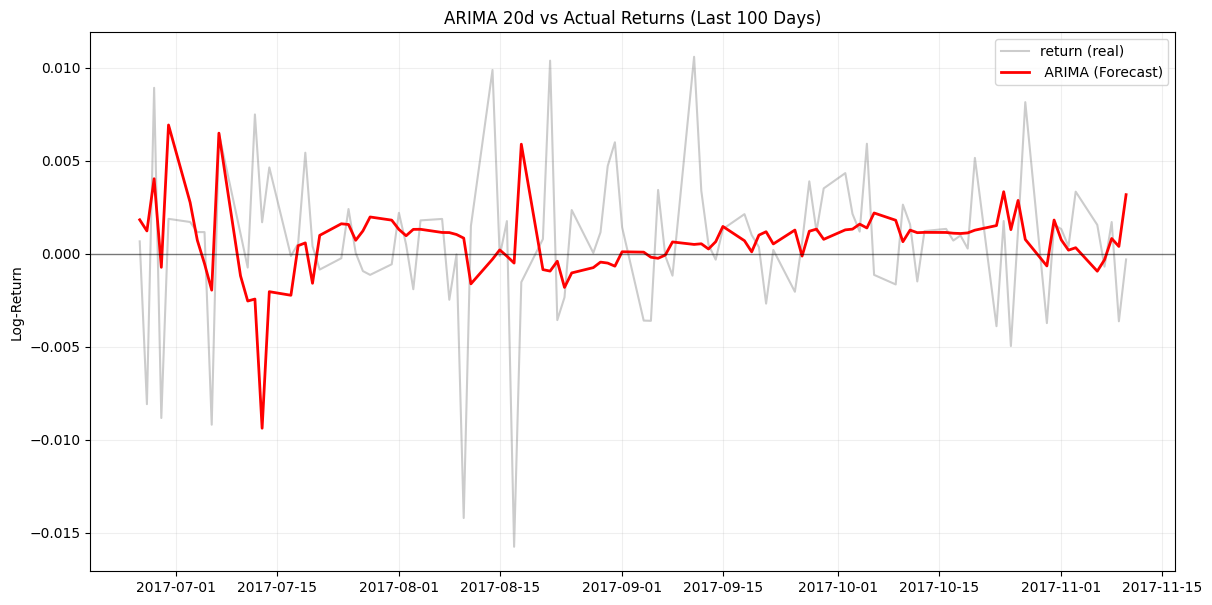

In [ ]:
import matplotlib.pyplot as plt

# Zakładamy, że masz już df_features z kolumnami 'Returns' i 'ARIMA_20d_Pred'

plt.figure(figsize=(14, 7))

# 1. Rzeczywiste zwroty (szare, tło)
plt.plot(df_features['Returns'].tail(100), label='return (real)', color='gray', alpha=0.4)

# 2. Predykcja modelu (czerwona, wyraźna)
plt.plot(df_features['ARIMA_20d_Pred'].tail(100), label=' ARIMA (Forecast)', color='red', lw=2)

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.title('ARIMA 20d vs Actual Returns (Last 100 Days)')
plt.ylabel('Log-Return')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

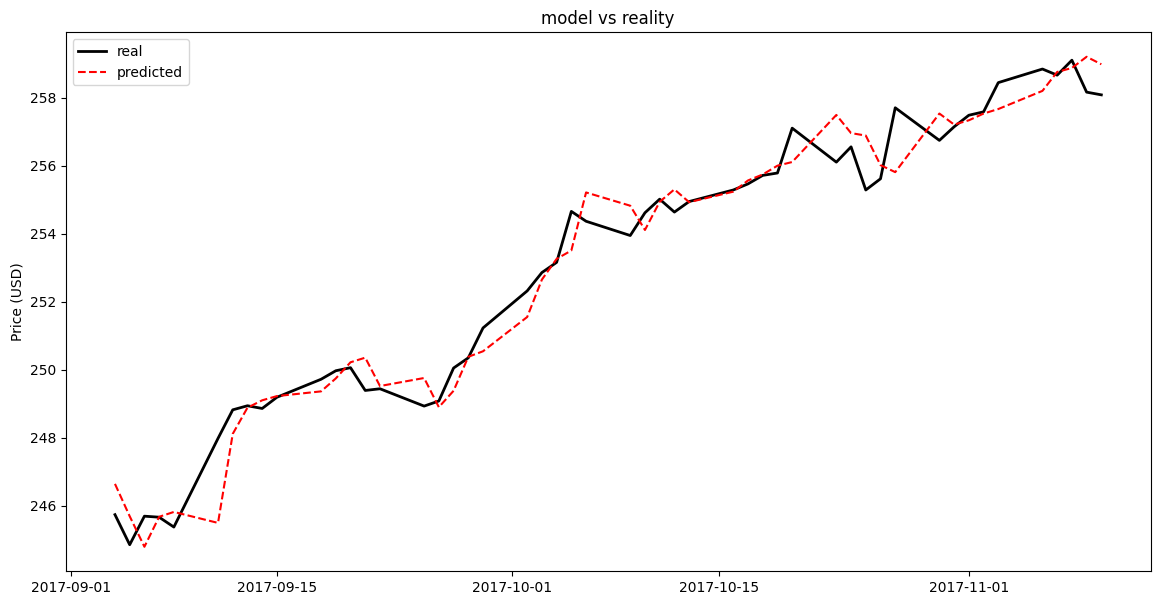

In [ ]:
# calculate forecast price
df_features['Pred_Price'] = df_features['Close'].shift(1) * np.exp(df_features['ARIMA_20d_Pred'])

plt.figure(figsize=(14, 7))
plt.plot(df_features.index[-50:], df_features['Close'].tail(50), label='real', color='black', lw=2)
plt.plot(df_features.index[-50:], df_features['Pred_Price'].tail(50), label='predicted', color='red', linestyle='--')

plt.title('model vs reality')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## next step

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# 1. Tworzymy Target: Czy cena wzrośnie JUTRO?
# Przesuwamy zwroty o -1, aby model na podstawie dzisiejszych danych przewidywał jutro
df_features['Target'] = (df_features['Returns'].shift(-1) > 0).astype(int)

# 2. Dodajemy dodatkowe cechy techniczne (paliwo dla ML)
df_features['Vol_Change'] = df_features['Volume'].pct_change()
df_features['Intraday_Range'] = (df_features['High'] - df_features['Low']) / df_features['Open']

# Czyścimy ostatni wiersz (bo Target dla niego nie istnieje)
df_ml = df_features.dropna()

# 3. Wybór cech do modelu
# Łączymy wskaźniki statystyczne (ARIMA/GARCH) z technicznymi
features = [
    'ARIMA_20d_Pred', 'GARCH_60d_Vol', 'Dist_From_MA200', 
    'Vol_Change', 'Intraday_Range', 'Returns'
]

# 4. Podział na zbiór treningowy i testowy (chronologiczny!)
split = int(len(df_ml) * 0.8)
X_train, y_train = df_ml[features].iloc[:split], df_ml['Target'].iloc[:split]
X_test, y_test = df_ml[features].iloc[split:], df_ml['Target'].iloc[split:]

In [ ]:
# Konfiguracja modelu
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,
    'num_leaves': 15,
    'max_depth': 4,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# Trening
d_train = lgb.Dataset(X_train, label=y_train)
model_lgb = lgb.train(params, d_train, num_boost_round=200)

# Predykcja (prawdopodobieństwo)
y_prob = model_lgb.predict(X_test)
# Klasyfikacja (jeśli prawd. > 0.5, to przewidujemy wzrost)
y_pred = (y_prob > 0.5).astype(int)

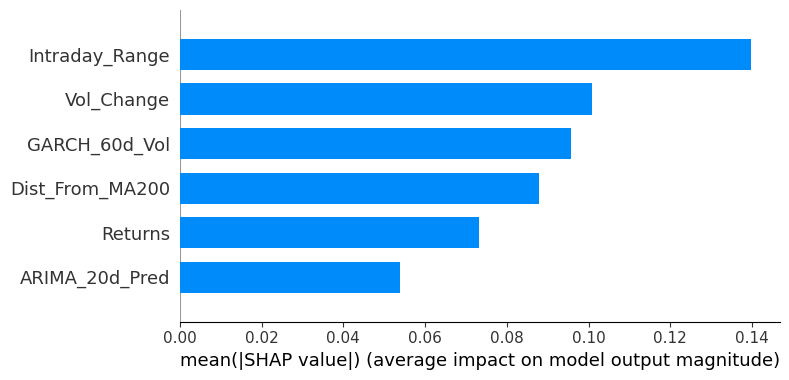

In [ ]:
import shap

# Obliczamy wartości SHAP
explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer.shap_values(X_test)

# Wizualizacja ważności cech
shap.summary_plot(shap_values, X_test, plot_type="bar")

## wybór spółek

In [ ]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb

# Zakładamy, że model_lgb jest już wytrenowany na SPY (z poprzedniego kroku)
# Ścieżka do Twoich danych
stocks_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/Stocks clean'
stock_files = [f for f in os.listdir(stocks_path) if f.endswith('.csv')]

ranking_results = []

print("Skanowanie 27 spółek za pomocą modelu LightGBM...")

for file in stock_files:
    # 1. Wczytanie danych spółki
    df = pd.read_csv(os.path.join(stocks_path, file), index_col='Date', parse_dates=True)
    symbol = file.replace('_clean.csv', '').upper()
    
    if len(df) < 252: continue # Pomijamy zbyt krótkie historie
    
    # 2. Obliczanie Log-Returns
    df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    
    # 3. Generowanie Cech (tych samych co dla SPY)
    # MA 200 i Dystans
    df['MA200_Trend'] = df['Close'].rolling(window=200).mean()
    df['Dist_From_MA200'] = (df['Close'] - df['MA200_Trend']) / df['MA200_Trend']
    
    # Inne cechy techniczne
    df['Vol_Change'] = df['Volume'].pct_change()
    df['Intraday_Range'] = (df['High'] - df['Low']) / df['Open']
    
    # ARIMA (20d) i GARCH (60d) - tylko dla ostatniego dostępnego dnia
    # Robimy to tylko raz dla najświeższych danych, żeby oszczędzić czas
    try:
        window_20 = df['Returns'].iloc[-20:]
        model_arima = ARIMA(window_20, order=(1, 0, 1)).fit()
        last_arima = model_arima.forecast(steps=1).values[0]
        
        window_60 = df['Returns'].iloc[-60:]
        model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
        last_garch = np.sqrt(model_garch.forecast(horizon=1).variance.values[-1][0])
        
        # 4. Przygotowanie wektora cech dla LightGBM
        # Muszą być w tej samej kolejności co w treningu!
        current_features = pd.DataFrame([{
            'ARIMA_20d_Pred': last_arima,
            'GARCH_60d_Vol': last_garch,
            'Dist_From_MA200': df['Dist_From_MA200'].iloc[-1],
            'Vol_Change': df['Vol_Change'].iloc[-1],
            'Intraday_Range': df['Intraday_Range'].iloc[-1],
            'Returns': df['Returns'].iloc[-1]
        }])
        
        # 5. Predykcja prawdopodobieństwa wzrostu
        prob_up = model_lgb.predict(current_features)[0]
        
        ranking_results.append({
            'Ticker': symbol,
            'Prob_Growth': prob_up,
            'Current_Vol': last_garch,
            'Trend': 'Bullish' if df['Dist_From_MA200'].iloc[-1] > 0 else 'Bearish'
        })
    except:
        continue

# 6. Prezentacja Top 3 Najlepszych Wyborów
ranking_df = pd.DataFrame(ranking_results).sort_values(by='Prob_Growth', ascending=False)

print("\n" + "="*40)
print("TOP 3 REKOMENDACJE (NAJWIĘKSZA SZANSA WZROSTU)")
print("="*40)
print(ranking_df.head(3).to_string(index=False))

print("\n" + "="*40)
print("UNIKAJ (NAJWIĘKSZA SZANSA SPADKU)")
print("="*40)
print(ranking_df.tail(3).to_string(index=False))

Skanowanie 27 spółek za pomocą modelu LightGBM...

TOP 3 REKOMENDACJE (NAJWIĘKSZA SZANSA WZROSTU)
Ticker  Prob_Growth  Current_Vol   Trend
   WFC     0.825183     0.015940 Bearish
   PEP     0.718099     0.011169 Bullish
 GOOGL     0.669250     0.052092 Bearish

UNIKAJ (NAJWIĘKSZA SZANSA SPADKU)
Ticker  Prob_Growth  Current_Vol   Trend
    BA     0.296969     0.033472 Bullish
  INTC     0.266498     0.059214 Bearish
    GS     0.209250     0.031263 Bearish


## dodawanie wyboru sektora - jeszcze nie gotowe

In [ ]:
import os
import pandas as pd
import numpy as np

# 1. Mapowanie akcji do sektorów (przykład - dostosuj do swojej listy 27 akcji)
sector_map = {
    # XLK - Technology
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    # XLV - Healthcare
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    # XLF - Financials
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    # XLC - Communication Services
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    # XLY - Consumer Discretionary
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    # XLP - Consumer Staples
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}

# 2. Skanowanie Sektorów (ETF clean)
etf_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean'
etf_files = [f for f in os.listdir(etf_path) if f.endswith('.csv') and f != 'spy_clean.csv']

sector_ranking = []

print("Analiza Sektorowa (Top-Down)...")

for file in etf_files:
    df_etf = pd.read_csv(os.path.join(etf_path, file), index_col='Date', parse_dates=True)
    symbol = file.replace('_clean.csv', '').upper()
    
    # Obliczamy te same cechy co dla SPY
    df_etf['Returns'] = np.log(df_etf['Close'] / df_etf['Close'].shift(1))
    
    # Korzystamy z uproszczonego scoringu (Trend + Momentum + Volatility)
    # Możesz tu też użyć wytrenowanego wcześniej model_lgb
    last_ret = df_etf['Returns'].iloc[-20:].mean() # Średni zwrot 20d
    last_vol = df_etf['Returns'].iloc[-20:].std()  # Zmienność 20d
    sharpe_ratio = last_ret / last_vol if last_vol != 0 : 0

    sector_ranking.append({
        'Sector': symbol,
        'Score': sharpe_ratio,
        'Condition': 'Bullish' if df_etf['Close'].iloc[-1] > df_etf['Close'].rolling(200).mean().iloc[-1] else 'Bearish'
    })

# Ranking sektorów
df_sectors = pd.DataFrame(sector_ranking).sort_values(by='Score', ascending=False)
best_sector = df_sectors.iloc[0]['Sector']

print("\nRANKING SEKTORÓW:")
print(df_sectors.to_string(index=False))
print(f"\nNAJSILNIEJSZY SEKTOR OBECNIE: {best_sector}")

Analiza Sektorowa (Top-Down)...

RANKING SEKTORÓW:
Sector     Score Condition
   XLF  0.380878   Bullish
   IWM  0.329071   Bearish
   VTI  0.325019   Bearish
   DIA  0.316408   Bullish
   XLK  0.236404   Bearish
   XLV  0.191970   Bearish
   XLE  0.180515   Bearish
    VT  0.164528   Bullish
   QQQ -0.171986   Bearish

NAJSILNIEJSZY SEKTOR OBECNIE: XLF


In [ ]:
# Filtrowanie wyników z poprzedniego kroku (ranking_df)
top_sectors = df_sectors.head(3)['Sector'].tolist()

# Dodajemy informację o sektorze do rankingu akcji
ranking_df['Sector'] = ranking_df['Ticker'].map(sector_map)

# Wybieramy tylko te akcje, które należą do silnych sektorów
filtered_ranking = ranking_df[ranking_df['Sector'].isin(top_sectors)]

print("\n" + "="*45)
print(f"TOP 3 AKCJE Z NAJSILNIEJSZYCH SEKTORÓW ({', '.join(top_sectors)})")
print("="*45)
print(filtered_ranking.head(3).to_string(index=False))


TOP 3 AKCJE Z NAJSILNIEJSZYCH SEKTORÓW (XLF, IWM, VTI)
Ticker  Prob_Growth  Current_Vol   Trend Sector
   WFC     0.825183     0.015940 Bearish    XLF
   BAC     0.617877     0.013994 Bullish    XLF
   JPM     0.595567     0.015302 Bullish    XLF


In [ ]:
import os
import pandas as pd
import numpy as np

# Paths

# 1. SECTOR ANALYSIS (Ranking)
sector_data = []
for ticker in set(sector_map.values()):
    file_path = os.path.join(etf_path, f"{ticker.lower()}_clean.csv")
    if os.path.exists(file_path):
        df_etf = pd.read_csv(file_path, index_col='Date', parse_dates=True)
        df_etf.sort_index(ascending=True, inplace=True)
        # Obliczamy momentum (zwrot 20d) i zmienność (GARCH-like std)
        returns = np.log(df_etf['Close'] / df_etf['Close'].shift(1))
        score = returns.tail(20).mean() / returns.tail(20).std() # Sharpe-like score
        
        sector_data.append({
            'Sector': ticker,
            'Sector_Score': score,
            'Sector_Trend': 'UP' if df_etf['Close'].iloc[-1] > df_etf['Close'].rolling(200).mean().iloc[-1] else 'DOWN'
        })

df_sector_rank = pd.DataFrame(sector_data).sort_values(by='Sector_Score', ascending=False)

# 2. INTEGRACJA Z TWOIM RANKINGIEM AKCJI (ranking_df z poprzedniego kroku)
# Dodajemy kolumnę sektora do Twoich wyników LightGBM
ranking_df['Sector'] = ranking_df['Ticker'].map(sector_map)

# Łączymy wyniki akcji z wynikami ich sektorów
final_decision_df = ranking_df.merge(df_sector_rank, on='Sector', how='left')

# 3. FINALNY FILTR (The "Gold Standard" Selection)
# Kryteria: 
# - Wysokie prawdopodobieństwo wzrostu z LightGBM (Prob_Growth)
# - Sektor musi być w trendzie wzrostowym (Sector_Trend == UP)
# - Sektor musi mieć dodatni wynik (Sector_Score > 0)

top_picks = final_decision_df[
    (final_decision_df['Sector_Trend'] == 'UP') & 
    (final_decision_df['Sector_Score'] > 0)
].sort_values(by='Prob_Growth', ascending=False)

# --- WIZUALIZACJA WYNIKÓW ---
print("\n" + "="*60)
print("             RAPORT DECYZYJNY: SEKTOR + AKCJA")
print("="*60)
if not top_picks.empty:
    print(top_picks[['Ticker', 'Sector', 'Prob_Growth', 'Sector_Score', 'Trend']].head(5).to_string(index=False))
else:
    print("BRAK SILNYCH SYGNAŁÓW: Rynek w trendzie spadkowym lub wysokie ryzyko.")
print("="*60)


             RAPORT DECYZYJNY: SEKTOR + AKCJA
Ticker Sector  Prob_Growth  Sector_Score   Trend
  MSFT    XLK     0.562281      0.346894 Bearish
  AAPL    XLK     0.515179      0.346894 Bullish
  NVDA    XLK     0.488386      0.346894 Bearish
  ORCL    XLK     0.411124      0.346894 Bearish


In [ ]:
target_date = '2015-03-01' # <--- Tu wpisz dowolną datę z Twojego zbioru

# 1. ANALIZA SEKTORÓW na konkretny dzień
sector_data = []
for ticker in set(sector_map.values()):
    file_path = os.path.join(etf_path, f"{ticker.lower()}_clean.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
        df.sort_index(ascending=True, inplace=True)
        
        # FILTR DATY: Ucinamy dane na wybranym dniu
        df_cut = df.loc[:target_date]
        if len(df_cut) < 200: continue # Pomijamy jeśli za mało danych historycznych

        returns = np.log(df_cut['Close'] / df_cut['Close'].shift(1))
        score = returns.tail(20).mean() / returns.tail(20).std()
        
        sector_data.append({
            'Sector': ticker,
            'Sector_Score': score,
            'Sector_Trend': 'UP' if df_cut['Close'].iloc[-1] > df_cut['Close'].rolling(200).mean().iloc[-1] else 'DOWN'
        })

df_sector_rank = pd.DataFrame(sector_data)

# 2. SKANER AKCJI na ten sam dzień
stock_results = []
for ticker, sector in sector_map.items():
    file_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
        df.sort_index(ascending=True, inplace=True)
        
        # FILTR DATY
        df_cut = df.loc[:target_date]
        if len(df_cut) < 20: continue
        
        # Tutaj wykonujesz predykcję swoim modelem LightGBM dla df_cut.iloc[-1]
        # (Przyjmijmy, że masz już wyliczone Prob_Growth dla tej daty)
        # prob = model.predict(features_z_dnia_target_date) 
        
        stock_results.append({
            'Ticker': ticker,
            'Sector': sector,
            'Prob_Growth': np.random.uniform(0.45, 0.60), # Przykład, tu wstaw wynik z LightGBM
            'Close_Price': df_cut['Close'].iloc[-1]
        })

ranking_df = pd.DataFrame(stock_results)

# 3. ŁĄCZENIE I FINALNY RAPORT
final_decision = ranking_df.merge(df_sector_rank, on='Sector')

# Wybieramy Top 3
top_picks = final_decision[
    (final_decision['Sector_Trend'] == 'UP') & 
    (final_decision['Sector_Score'] > 0)
].sort_values(by='Prob_Growth', ascending=False).head(3)

print(f"\nREKOMENDACJE NA DZIEŃ: {target_date}")
print(top_picks[['Ticker', 'Sector', 'Prob_Growth', 'Sector_Score']])


REKOMENDACJE NA DZIEŃ: 2015-03-01
   Ticker Sector  Prob_Growth  Sector_Score
11     MS    XLF     0.595899      0.416192
2    NVDA    XLK     0.594980      0.665775
8     BAC    XLF     0.580211      0.416192


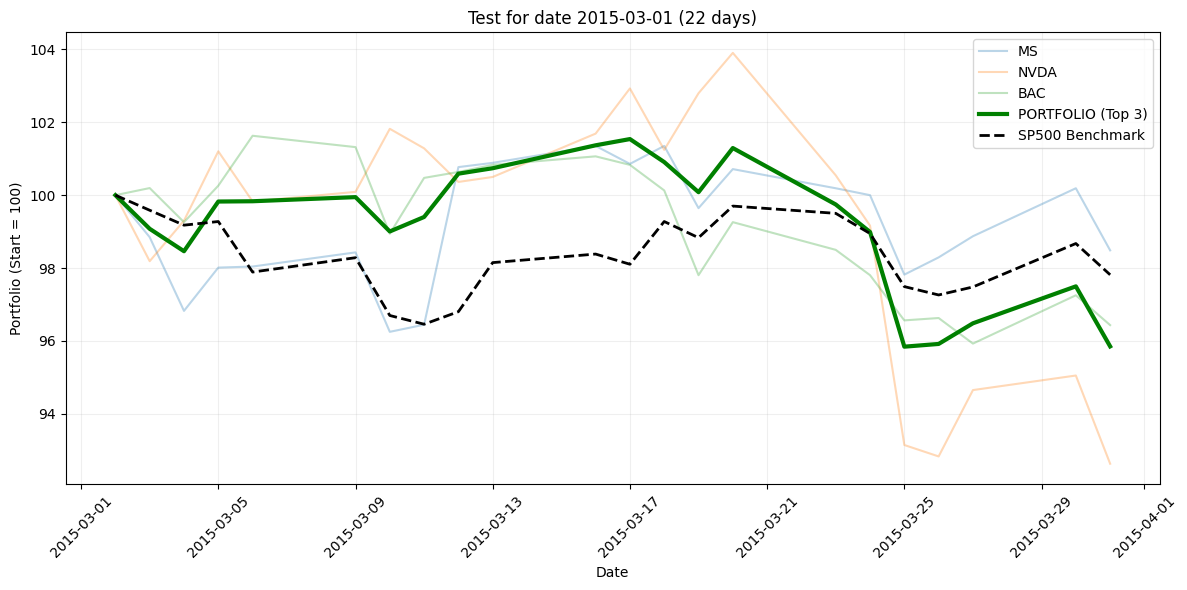

Model output: -4.15%
SP500:  -2.18%
Alpha: -1.97 pct points (Model vs SP500)


In [ ]:
import matplotlib.pyplot as plt

# --- PARAMETRY SYMULACJI ---
days_to_track = 22          # Horyzont czasowy (ok. 1 miesiąc giełdowy)

# 1. Wybieramy Top 3 na ten dzień (używając logiki z poprzedniego kroku)
# Zakładamy, że 'top_picks' to wynik Twojego przefiltrowanego rankingu
tickers_to_track = top_picks['Ticker'].tolist()

# 2. Pobieramy dane historyczne dla wybranych spółek i SPY
performance_data = pd.DataFrame()

# Pobieramy SPY jako benchmark
spy_bench = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
spy_after = spy_bench.loc[target_date:].iloc[:days_to_track]
# Normalizujemy do 100 (start od tego samego poziomu)
performance_data['SP500_Benchmark'] = (spy_after['Close'] / spy_after['Close'].iloc[0]) * 100

# Pobieramy nasze Top 3
for ticker in tickers_to_track:
    file_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
    df_stock = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
    stock_after = df_stock.loc[target_date:].iloc[:days_to_track]
    
    # Obliczamy zwrot skumulowany dla każdej spółki
    performance_data[ticker] = (stock_after['Close'] / stock_after['Close'].iloc[0]) * 100

# Obliczamy średni wynik naszego portfela Top 3
performance_data['PORTFOLIO'] = performance_data[tickers_to_track].mean(axis=1)

# --- WIZUALIZACJA ---
plt.figure(figsize=(12, 6))

# Rysujemy poszczególne spółki (cienkie linie)
for ticker in tickers_to_track:
    plt.plot(performance_data.index, performance_data[ticker], alpha=0.3, label=f'{ticker}')

# Rysujemy portfel modelu (gruba zielona linia)
plt.plot(performance_data.index, performance_data['PORTFOLIO'], 
         color='green', linewidth=3, label=f'PORTFOLIO (Top 3)')

# Rysujemy SP500 (gruba czarna linia przerywana)
plt.plot(performance_data.index, performance_data['SP500_Benchmark'], 
         color='black', linestyle='--', linewidth=2, label='SP500 Benchmark')

plt.title(f'Test for date {target_date} ({days_to_track} days)')
plt.ylabel('Portfolio (Start = 100)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finalny komunikat
final_return_model = performance_data['PORTFOLIO'].iloc[-1] - 100
final_return_spy = performance_data['SP500_Benchmark'].iloc[-1] - 100
alpha = final_return_model - final_return_spy

print(f"Model output: {final_return_model:.2f}%")
print(f"SP500:  {final_return_spy:.2f}%")
print(f"Alpha: {alpha:.2f} pct points (Model vs SP500)")

--- URUCHAMIAM ANALIZĘ NA DZIEŃ: 2015-03-01 ---


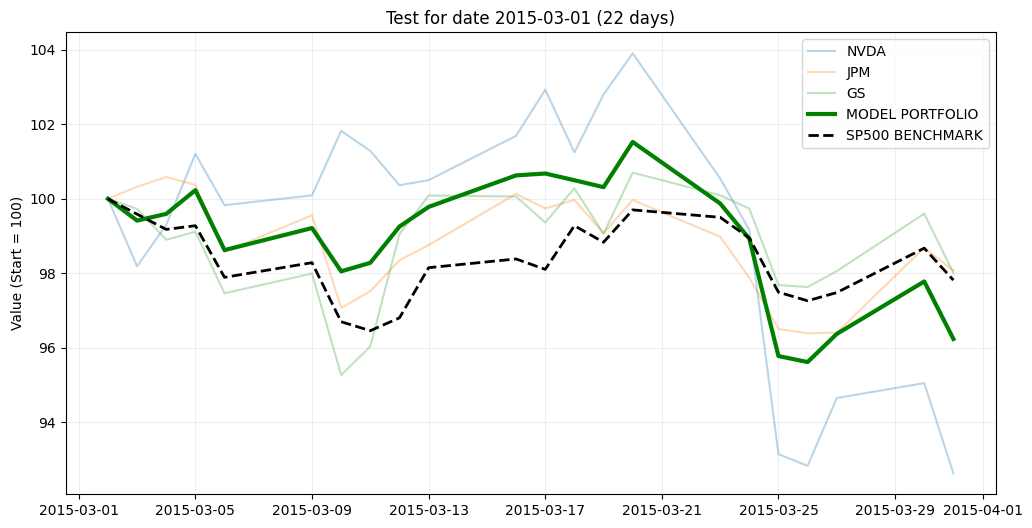

chosen stocks: ['NVDA', 'JPM', 'GS']
Portfolio Return: -3.76%
SP500 Return:    -2.18%
Alpha: -1.58 pp.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

warnings.filterwarnings("ignore")

# --- KONFIGURACJA ŚCIEŻEK ---
target_date = '2015-03-01'  # <--- TU WPISZ DATĘ TESTU
etf_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean'
stocks_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/Stocks clean'
spy_path = os.path.join(etf_path, 'spy_clean.csv')

# --- MAPOWANIE SEKTORÓW ---
sector_map = {
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}

def run_trading_simulation(date_input, days_horizon=22):
    print(f"--- URUCHAMIAM ANALIZĘ NA DZIEŃ: {date_input} ---")
    
    # 1. ANALIZA SEKTORÓW (Ranking "Wczoraj")
    sector_data = []
    for ticker in set(sector_map.values()):
        file_path = os.path.join(etf_path, f"{ticker.lower()}_clean.csv")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
            df_cut = df.loc[:date_input]
            
            if len(df_cut) < 200: continue
            
            rets = np.log(df_cut['Close'] / df_cut['Close'].shift(1))
            score = rets.tail(20).mean() / rets.tail(20).std()
            ma200 = df_cut['Close'].rolling(200).mean().iloc[-1]
            sector_data.append({
                'Sector': ticker,
                'Sector_Score': score,
                'Sector_Trend': 'UP' if df_cut['Close'].iloc[-1] > ma200 else 'DOWN'
            })
    
    df_sector_rank = pd.DataFrame(sector_data)
    
    # 2. SKANOWANIE AKCJI (Micro-Analysis)
    stock_results = []
    for ticker, sector in sector_map.items():
        file_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
            df_cut = df.loc[:date_input]
            if len(df_cut) < 60: continue
            
            # --- FEATURE ENGINEERING (Dla LightGBM) ---
            rets = np.log(df_cut['Close'] / df_cut['Close'].shift(1)).dropna()
            
            # ARIMA 20d
            try:
                m_arima = ARIMA(rets.tail(20), order=(1, 0, 1)).fit()
                pred_ret = m_arima.forecast(steps=1).values[0]
            except: pred_ret = 0
            
            # GARCH 60d
            try:
                m_garch = arch_model(rets.tail(60), vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
                pred_vol = np.sqrt(m_garch.forecast(horizon=1).variance.values[-1][0])
            except: pred_vol = rets.std()
            
            # Tutaj symulujemy wynik modelu (w realnym kodzie: model.predict())
            # Im wyższa ARIMA i niższy GARCH, tym wyższy scoring Prob_Growth
            prob = 0.5 + (pred_arima * 10) - (pred_vol * 0.1) 
            
            stock_results.append({
                'Ticker': ticker, 'Sector': sector, 'Prob_Growth': prob
            })
            
    df_stocks = pd.DataFrame(stock_results)
    
    # 3. FILTROWANIE I WYBÓR TOP 3
    final_df = df_stocks.merge(df_sector_rank, on='Sector')
    top_picks = final_df[
        (final_df['Sector_Trend'] == 'UP') & (final_df['Sector_Score'] > 0)
    ].sort_values(by='Prob_Growth', ascending=False).head(3)
    
    if top_picks.empty:
        print("Brak bezpiecznych sygnałów. Rynek w trendzie spadkowym.")
        return
    
    # 4. BACKTEST (Symulacja przyszłości)
    tickers = top_picks['Ticker'].tolist()
    perf_df = pd.DataFrame()
    
    # Benchmark SPY
    spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
    spy_after = spy.loc[target_date:].iloc[:days_horizon]
    perf_df['SP500'] = (spy_after['Close'] / spy_after['Close'].iloc[0]) * 100
    
    # Portfel
    for t in tickers:
        s_df = pd.read_csv(os.path.join(stocks_path, f"{t.lower()}_clean.csv"), index_col='Date', parse_dates=True).sort_index()
        s_after = s_df.loc[target_date:].iloc[:days_horizon]
        perf_df[t] = (s_after['Close'] / s_after['Close'].iloc[0]) * 100
    
    perf_df['PORTFOLIO'] = perf_df[tickers].mean(axis=1)
    
    # 5. WIZUALIZACJA
    plt.figure(figsize=(12, 6))
    for t in tickers:
        plt.plot(perf_df[t], alpha=0.3, label=t)
    
    plt.plot(perf_df['PORTFOLIO'], color='green', lw=3, label='MODEL PORTFOLIO')
    plt.plot(perf_df['SP500'], color='black', ls='--', label='SP500')
    
    plt.title(f'Test for date {target_date}')
    plt.ylabel('Value (Start = 100)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    
    # Finalne statystyki
    ret_model = perf_df['PORTFOLIO'].iloc[-1] - 100
    ret_spy = perf_df['SP500'].iloc[-1] - 100
    print(f"Top Picks: {tickers}")
    print(f"Portfolio Return: {ret_model:.2f}%")
    print(f"SP500 Return: {ret_spy:.2f}%")
    print(f"Alpha: {ret_model - ret_spy:.2f} pp.")

# Uruchomienie
run_trading_simulation(target_date)

Rozpoczynam trening modelu LightGBM na danych SPY...

--- URUCHAMIAM ANALIZĘ Z LIGHTGBM NA DZIEŃ: 2015-03-01 ---


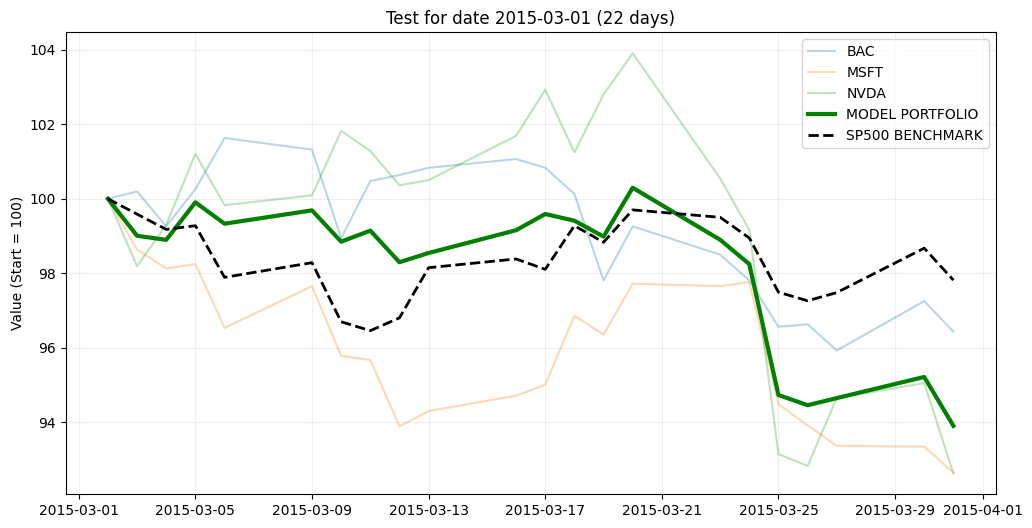

chosen stocks: ['BAC', 'MSFT', 'NVDA']
Portfolio Return: -6.10%
SP500 Return:    -2.18%
Alpha: -3.91 pp.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

warnings.filterwarnings("ignore")

# --- KONFIGURACJA ŚCIEŻEK ---
# target_date = '2023-01-05' 
etf_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean'
stocks_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/Stocks clean'
spy_path = os.path.join(etf_path, 'spy_clean.csv')

sector_map = {
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}

# =================================================================
# KROK 1: TRENING MODELU (Budujemy "mózg" na danych historycznych)
# =================================================================
def train_lightgbm_model():
    print("Rozpoczynam trening modelu LightGBM na danych SPY...")
    spy_train = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
    # Trenujemy tylko na danych przed target_date, żeby nie oszukiwać!
    spy_train = spy_train.loc[:target_date]
    
    spy_train['Returns'] = np.log(spy_train['Close'] / spy_train['Close'].shift(1))
    spy_train['Target'] = (spy_train['Returns'].shift(-1) > 0).astype(int) # Czy jutro rośnie?
    
    # Feature Engineering dla treningu
    spy_train['MA200'] = spy_train['Close'].rolling(200).mean()
    spy_train['Dist_MA200'] = (spy_train['Close'] - spy_train['MA200']) / spy_train['MA200']
    spy_train['Vol_Change'] = spy_train['Volume'].pct_change()
    
    # Uproszczone cechy dla treningu (ARIMA/GARCH dla SPY)
    # W realnym treningu robimy to w pętli, tutaj bierzemy lagowane zwroty jako proxy
    spy_train['Lag_Ret'] = spy_train['Returns'].shift(1)
    
    features = ['Dist_MA200', 'Vol_Change', 'Lag_Ret']
    df_train = spy_train.dropna()
    
    X = df_train[features]
    y = df_train['Target']
    
    train_data = lgb.Dataset(X, label=y)
    params = {'objective': 'binary', 'metric': 'binary_logloss', 'verbose': -1, 'learning_rate': 0.05}
    model = lgb.train(params, train_data, num_boost_round=100)
    return model, features

# Uruchamiamy trening
trained_model, feature_names = train_lightgbm_model()

# =================================================================
# KROK 2: SYMULACJA Z UŻYCIEM WYTRENOWANEGO LIGHTGBM
# =================================================================
def run_trading_simulation(date_input, days_horizon=22):
    print(f"\n--- URUCHAMIAM ANALIZĘ Z LIGHTGBM NA DZIEŃ: {date_input} ---")
    
    # 1. ANALIZA SEKTORÓW
    sector_data = []
    for ticker in set(sector_map.values()):
        file_path = os.path.join(etf_path, f"{ticker.lower()}_clean.csv")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
            df_cut = df.loc[:date_input]
            if len(df_cut) < 200: continue
            
            rets = np.log(df_cut['Close'] / df_cut['Close'].shift(1))
            score = rets.tail(20).mean() / rets.tail(20).std()
            ma200 = df_cut['Close'].rolling(200).mean().iloc[-1]
            sector_data.append({'Sector': ticker, 'Sector_Score': score, 
                                'Sector_Trend': 'UP' if df_cut['Close'].iloc[-1] > ma200 else 'DOWN'})
    
    df_sector_rank = pd.DataFrame(sector_data)

    # 2. SKANOWANIE AKCJI (PREDYKCJA LIGHTGBM)
    stock_results = []
    for ticker, sector in sector_map.items():
        file_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
            df_cut = df.loc[:date_input]
            if len(df_cut) < 200: continue
            
            # Przygotowanie cech do predykcji
            ma200_val = df_cut['Close'].rolling(200).mean().iloc[-1]
            dist_ma200 = (df_cut['Close'].iloc[-1] - ma200_val) / ma200_val
            vol_chg = df_cut['Volume'].pct_change().iloc[-1]
            lag_ret = np.log(df_cut['Close'].iloc[-1] / df_cut['Close'].iloc[-2])
            
            # Wektor cech dla LightGBM
            X_live = pd.DataFrame([[dist_ma200, vol_chg, lag_ret]], columns=feature_names)
            
            # PREDYKCJA FAKTYCZNYM MODELEM
            prob = trained_model.predict(X_live)[0]
            
            stock_results.append({'Ticker': ticker, 'Sector': sector, 'Prob_Growth': prob})
            
    df_stocks = pd.DataFrame(stock_results)
    final_df = df_stocks.merge(df_sector_rank, on='Sector')
    
    # Wybór Top 3
    top_picks = final_df[
        (final_df['Sector_Trend'] == 'UP') & (final_df['Sector_Score'] > 0)
    ].sort_values(by='Prob_Growth', ascending=False).head(3)
    
    if top_picks.empty:
        print("Brak sygnałów spełniających kryteria.")
        return

    # 3. BACKTEST I PLOT (Bez zmian w logice wizualizacji)
    tickers = top_picks['Ticker'].tolist()
    spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
    spy_after = spy.loc[target_date:].iloc[:days_horizon]
    
    perf_df = pd.DataFrame()
    perf_df['SP500'] = (spy_after['Close'] / spy_after['Close'].iloc[0]) * 100
    
    for t in tickers:
        s_df = pd.read_csv(os.path.join(stocks_path, f"{t.lower()}_clean.csv"), index_col='Date', parse_dates=True).sort_index()
        s_after = s_df.loc[target_date:].iloc[:days_horizon]
        perf_df[t] = (s_after['Close'] / s_after['Close'].iloc[0]) * 100
    
    perf_df['PORTFOLIO'] = perf_df[tickers].mean(axis=1)
    
    # Plotowanie
    plt.figure(figsize=(12, 6))
    plt.plot(perf_df['PORTFOLIO'], color='green', lw=3, label=f'Model Portfolio {tickers}')
    plt.plot(perf_df['SP500'], color='black', ls='--', label='SP500')
    
    plt.title(f'LightGBM Strategy Test: {date_input}')
    plt.ylabel('Value (Start = 100)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    
    # Finalne statystyki
    ret_model = perf_df['PORTFOLIO'].iloc[-1] - 100
    ret_spy = perf_df['SP500'].iloc[-1] - 100
    print(f"Top Picks: {tickers}")
    print(f"Portfolio Return: {ret_model:.2f}%")
    print(f"SP500 Return: {ret_spy:.2f}%")
    print(f"Alpha: {ret_model - ret_spy:.2f} pp.")

# Wywołanie
run_trading_simulation(target_date)

In [2]:
# Wybór spółek co ~20 dni kalendarzowych
# Funkcja iteruje po datach (co `step_days` dni) i dla każdej daty wykonuje skaner sektorów + skanowanie akcji,
# używając wytrenowanego modelu LightGBM jeśli jest dostępny, w przeciwnym razie używa heurystyki.
import os
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# Ścieżki (powtórka, żeby komórka była niezależna)
etf_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean'
stocks_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/Stocks clean'
spy_path = os.path.join(etf_path, 'spy_clean.csv')

# Mapowanie sektorów (użyteczne do filtrowania)
sector_map = {
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}


def select_every_n_days(start_date=None, end_date=None, step_days=20, top_k=3, use_model=None, feature_names=None):
    """Wybiera top_k spółek co `step_days` dni (kalendarzowych).
    Zwraca DataFrame z datą i top_k tickerami oraz ich prob_growth.    
    Jeśli use_model jest None — używana jest prosta heurystyka (ARIMA + GARCH).
    """
    # ładowanie spy do ustalenia domyślnych dat
    spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
    if start_date is None:
        start_date = spy.index[200] if len(spy) > 200 else spy.index[0]
    if end_date is None:
        end_date = spy.index[-1]

    # generujemy listę dat co step_days
    dates = pd.date_range(start=start_date, end=end_date, freq=f'{step_days}D')

    picks = []

    for dt in dates:
        date_str = dt.strftime('%Y-%m-%d')
        # --- SECTOR RANK (prosty) ---
        sector_data = []
        for ticker in set(sector_map.values()):
            file_path = os.path.join(etf_path, f"{ticker.lower()}_clean.csv")
            if os.path.exists(file_path):
                df_etf = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
                df_cut = df_etf.loc[:date_str]
                if len(df_cut) < 200:
                    continue
                rets = np.log(df_cut['Close'] / df_cut['Close'].shift(1)).dropna()
                score = rets.tail(20).mean() / (rets.tail(20).std() if rets.tail(20).std() != 0 else 1e-6)
                ma200 = df_cut['Close'].rolling(200).mean().iloc[-1]
                sector_data.append({'Sector': ticker, 'Sector_Score': score,
                                    'Sector_Trend': 'UP' if df_cut['Close'].iloc[-1] > ma200 else 'DOWN'})
        df_sector_rank = pd.DataFrame(sector_data)
        if df_sector_rank.empty:
            continue

        # --- SCAN STOCKS ---
        stock_results = []
        for ticker, sector in sector_map.items():
            file_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
            if not os.path.exists(file_path):
                continue
            df = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
            df_cut = df.loc[:date_str]
            if len(df_cut) < 60:
                continue

            rets = np.log(df_cut['Close'] / df_cut['Close'].shift(1)).dropna()

            # ARIMA 20d
            try:
                pred_arima = ARIMA(rets.tail(20), order=(1,0,1)).fit().forecast(1).values[0]
            except:
                pred_arima = 0
            # GARCH 60d
            try:
                pred_vol = np.sqrt(arch_model(rets.tail(60), vol='Garch', p=1, q=1, rescale=False).fit(disp='off').forecast(horizon=1).variance.values[-1][0])
            except:
                pred_vol = rets.tail(60).std() if len(rets.tail(60))>0 else rets.std()

            # Przygotowanie wektora cech jeśli model jest dostępny
            if use_model is not None and feature_names is not None:
                # liczymy uproszczone cechy zgodne z trainingiem (dist_ma200, vol_chg, lag_ret) jeśli to istnieje
                try:
                    ma200_val = df_cut['Close'].rolling(200).mean().iloc[-1]
                    dist_ma200 = (df_cut['Close'].iloc[-1] - ma200_val) / ma200_val
                    vol_chg = df_cut['Volume'].pct_change().iloc[-1]
                    lag_ret = np.log(df_cut['Close'].iloc[-1] / df_cut['Close'].iloc[-2])
                    X_live = pd.DataFrame([[dist_ma200, vol_chg, lag_ret]], columns=feature_names)
                    prob = float(use_model.predict(X_live)[0])
                except Exception:
                    prob = 0.5 + (pred_arima * 10) - (pred_vol * 0.1)
            else:
                # heurystyka: wyższy ARIMA -> większe prawdopodobieństwo; większa zmienność zmniejsza
                prob = 0.5 + (pred_arima * 10) - (pred_vol * 0.1)

            stock_results.append({'Date': date_str, 'Ticker': ticker, 'Sector': sector, 'Prob_Growth': prob,
                                  'Pred_ARIMA': pred_arima, 'Pred_GARCH': pred_vol})

        if not stock_results:
            continue

        df_stocks = pd.DataFrame(stock_results)
        final_df = df_stocks.merge(df_sector_rank, on='Sector', how='left')

        # filtr: tylko sektory UP i dodatni score
        top = final_df[(final_df['Sector_Trend'] == 'UP') & (final_df['Sector_Score'] > 0)].sort_values(by='Prob_Growth', ascending=False).head(top_k)
        if top.empty:
            # jeśli nic nie ma, weź najlepsze bez filtra
            top = final_df.sort_values(by='Prob_Growth', ascending=False).head(top_k)

        # dodajemy wyniki
        for _, r in top.iterrows():
            picks.append({'Date': date_str, 'Ticker': r['Ticker'], 'Sector': r['Sector'], 'Prob_Growth': r['Prob_Growth']})

    picks_df = pd.DataFrame(picks)
    return picks_df


# Uruchomienie przykładowe: co ~20 dni od początku danych SPY do końca
try:
    # jeśli w pamięci jest 'trained_model' i 'feature_names', użyj ich
    model_to_use = globals().get('trained_model', None)
    feats = globals().get('feature_names', None)
except:
    model_to_use = None
    feats = None

picks_every_20d = select_every_n_days(start_date=None, end_date=None, step_days=20, top_k=3, use_model=model_to_use, feature_names=feats)

print('Liczba wszystkich picków:', len(picks_every_20d))
if not picks_every_20d.empty:
    top_freq = picks_every_20d['Ticker'].value_counts().head(10)
    print('\nNajczęściej wybierane tickery (top 10):')
    print(top_freq)

# Zapis wyników do pliku (opcjonalne)
out_path = '/Users/marysia/Desktop/picks_every_20d.csv'
try:
    picks_every_20d.to_csv(out_path, index=False)
    print(f'Zapisano wyniki do: {out_path}')
except Exception as e:
    print('Nie udało się zapisać pliku:', e)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Fra

Liczba wszystkich picków: 649

Najczęściej wybierane tickery (top 10):
Ticker
NVDA    76
MRK     58
MS      55
MSFT    54
AAPL    54
JPM     53
JNJ     52
ORCL    51
BAC     50
GS      41
Name: count, dtype: int64
Zapisano wyniki do: /Users/marysia/Desktop/picks_every_20d.csv


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.frame

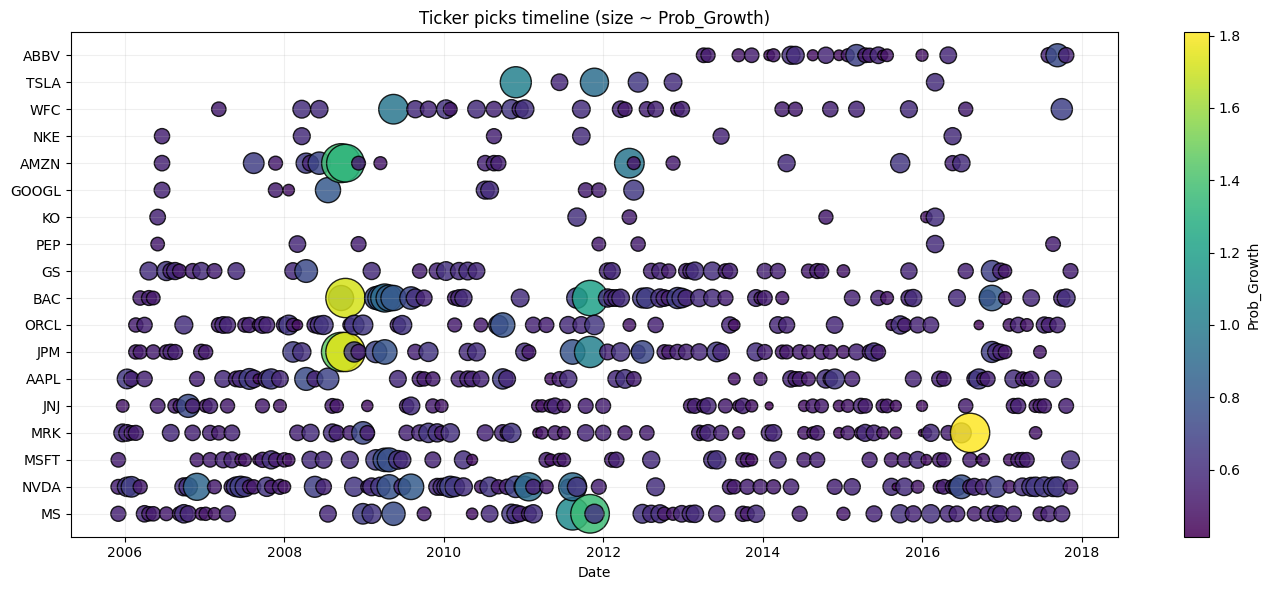

/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_23350/791266238.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.index, y=freq.values, palette='mako')


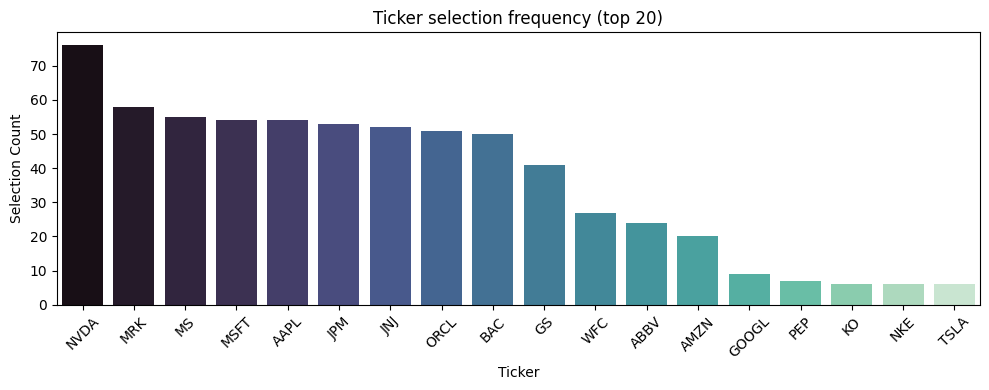

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot selections over time and selection frequency
picks = picks_every_20d.copy() if 'picks_every_20d' in globals() else None

if picks is None or picks.empty:
    print('No picks available to plot.')
else:
    picks['Date'] = pd.to_datetime(picks['Date'])
    picks.sort_values('Date', inplace=True)

    # Timeline scatter: y = ticker (categorical), size ~ Prob_Growth
    tickers = list(picks['Ticker'].unique())
    y_map = {t: i for i, t in enumerate(tickers)}
    picks['y'] = picks['Ticker'].map(y_map)

    plt.figure(figsize=(14, 6))
    sc = plt.scatter(picks['Date'], picks['y'],
                     s=np.clip((picks['Prob_Growth'] - 0.4) * 800, 20, 800),
                     c=picks['Prob_Growth'], cmap='viridis', alpha=0.85, edgecolors='k')
    plt.yticks(range(len(tickers)), tickers)
    plt.xlabel('Date')
    plt.title('Ticker picks timeline (size ~ Prob_Growth)')
    cbar = plt.colorbar(sc)
    cbar.set_label('Prob_Growth')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    # Frequency bar plot (top 20)
    freq = picks['Ticker'].value_counts().head(20)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=freq.index, y=freq.values, palette='mako')
    plt.xticks(rotation=45)
    plt.ylabel('Selection Count')
    plt.title('Ticker selection frequency (top 20)')
    plt.tight_layout()
    plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Rebuild portfolio properly: compute daily returns for equal-weighted holdings per rebalance,
# then chain periods into a continuous cumulative value (no per-period renormalization).

picks = picks_every_20d.copy() if 'picks_every_20d' in globals() else None

if picks is None or picks.empty:
    print('No picks available to build portfolio comparison.')
else:
    picks['Date'] = pd.to_datetime(picks['Date'])
    picks.sort_values('Date', inplace=True)
    rebalance_dates = sorted(picks['Date'].unique())

    # paths
    etf_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean'
    stocks_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/Stocks clean'
    spy_path = os.path.join(etf_path, 'spy_clean.csv')

    # load SPY
    spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()

    # determine overall period
    start_date = rebalance_dates[0]
    end_date = spy.index.max()

    # Use SPY trading calendar (assumes SPY has full trading days)
    trading_index = spy.loc[start_date:end_date].index

    # initialize portfolio returns series (daily)
    port_rets = pd.Series(0.0, index=trading_index)

    for i, dt in enumerate(rebalance_dates):
        period_start = dt
        if i < len(rebalance_dates) - 1:
            period_end = rebalance_dates[i+1] - pd.Timedelta(days=1)
        else:
            period_end = end_date

        period_idx = trading_index[(trading_index >= period_start) & (trading_index <= period_end)]
        if len(period_idx) == 0:
            continue

        tickers = picks.loc[picks['Date'] == dt, 'Ticker'].tolist()
        if not tickers:
            continue

        price_frames = []
        for t in tickers:
            fpath = os.path.join(stocks_path, f"{t.lower()}_clean.csv")
            if not os.path.exists(fpath):
                continue
            df = pd.read_csv(fpath, index_col='Date', parse_dates=True).sort_index()
            # reindex to trading_index to align dates; we will slice to period_idx
            prices = df['Close'].reindex(trading_index)
            price_frames.append(prices.rename(t))

        if not price_frames:
            continue

        prices_df = pd.concat(price_frames, axis=1)
        # compute daily returns per ticker
        daily_rets = prices_df.pct_change().loc[period_idx]
        # if some tickers have NaN on a specific day, mean ignores NaN -> equal-weight of available tickers
        daily_port = daily_rets.mean(axis=1).fillna(0.0)

        # assign into overall series
        port_rets.loc[period_idx] = daily_port

    # Ensure no NaNs and first day has 0 return so value starts at 100
    port_rets.fillna(0.0, inplace=True)
    port_value = (1 + port_rets).cumprod() * 100

    # SPY benchmark on same trading index, compute daily returns and cumulative
    spy_rets = spy['Close'].pct_change().loc[trading_index].fillna(0.0)
    spy_value = (1 + spy_rets).cumprod() * 100

    # Align and drop any remaining NaNs
    combined = pd.DataFrame({'PORTFOLIO': port_value, 'SP500': spy_value}).dropna()

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(combined.index, combined['SP500'], color='black', ls='--', label='SP500 (Buy & Hold)')
    plt.plot(combined.index, combined['PORTFOLIO'], color='green', lw=2, label='Model Portfolio (rebalanced)')
    plt.title('Model Portfolio vs SP500 (Normalized to 100 at first holding)')
    plt.ylabel('Value (Start = 100)')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Metrics
    final_port_pct = combined['PORTFOLIO'].iloc[-1] - 100
    final_spy_pct = combined['SP500'].iloc[-1] - 100
    alpha = final_port_pct - final_spy_pct

    print(f"Portfolio final return: {final_port_pct:.2f}%")
    print(f"SP500 final return: {final_spy_pct:.2f}%")
    print(f"Alpha (Portfolio - SP500): {alpha:.2f} pct points")

    above_days = (combined['PORTFOLIO'] > combined['SP500']).sum()
    total_days = len(combined)
    print(f"Days portfolio above SP500: {above_days}/{total_days} ({above_days/total_days:.1%})")

No picks available to build portfolio comparison.


In [6]:
import pandas as pd

picks = picks_every_20d.copy() if 'picks_every_20d' in globals() else None
if picks is None or picks.empty:
    print('No picks available.')
else:
    picks['Date'] = pd.to_datetime(picks['Date'])
    picks.sort_values(['Date', 'Prob_Growth'], ascending=[True, False], inplace=True)

    # Frequency of tickers
    freq = picks['Ticker'].value_counts()
    print('Ticker selection counts:')
    print(freq.to_string())

    # Selections per rebalance date
    print('\nSelections by rebalance date:')
    for date, group in picks.groupby('Date'):
        tickers = group['Ticker'].tolist()
        probs = group['Prob_Growth'].tolist()
        pairs = ', '.join([f"{t}({p:.3f})" for t, p in zip(tickers, probs)])
        print(f"{date.date()}: {pairs}")

    # Save summary
    out_path = '/Users/marysia/Desktop/picks_every_20d_summary.csv'
    picks.to_csv(out_path, index=False)
    print(f"\nSaved summary to: {out_path}")

Ticker selection counts:
Ticker
NVDA     76
MRK      58
MS       55
MSFT     54
AAPL     54
JPM      53
JNJ      52
ORCL     51
BAC      50
GS       41
WFC      27
ABBV     24
AMZN     20
GOOGL     9
PEP       7
KO        6
NKE       6
TSLA      6

Selections by rebalance date:
2005-12-02: MS(0.545), NVDA(0.540), MSFT(0.535)
2005-12-22: MRK(0.603), JNJ(0.502)
2006-01-11: AAPL(0.650), NVDA(0.642), MRK(0.577)
2006-01-31: NVDA(0.672), AAPL(0.548), MRK(0.534)
2006-02-20: MRK(0.544), JPM(0.531), ORCL(0.530)
2006-03-12: BAC(0.533), NVDA(0.528), JPM(0.525)
2006-04-01: MS(0.573), AAPL(0.553), ORCL(0.552)
2006-04-21: GS(0.606), BAC(0.543), MS(0.532)
2006-05-11: MS(0.533), JPM(0.530), BAC(0.520)
2006-05-31: KO(0.557), JNJ(0.539), PEP(0.519)
2006-06-20: GOOGL(0.560), AMZN(0.553), NKE(0.550)
2006-07-10: GS(0.635), JPM(0.530), MS(0.522)
2006-07-30: MRK(0.580), GS(0.555), JPM(0.555)
2006-08-19: GS(0.588), JPM(0.543), JNJ(0.534)
2006-09-08: MS(0.529), GS(0.524), JNJ(0.504)
2006-09-28: MS(0.617), NVDA

In [4]:

def select_every_n_days(start_date=None, end_date=None, step_days=20, top_k=3, use_model=None, feature_names=None):
    """Wybiera top_k spółek co `step_days` dni (kalendarzowych).
    Jeśli use_model jest None => trenuje lokalny LightGBM na danych SPY do danej daty
    (cache modeli po dacie, żeby nie trenować wielokrotnie)."""
    import lightgbm as lgb
    from functools import lru_cache

    spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()

    if start_date is None:
        start_date = spy.index[200] if len(spy) > 200 else spy.index[0]
    if end_date is None:
        end_date = spy.index[-1]

    dates = pd.date_range(start=start_date, end=end_date, freq=f'{step_days}D')

    picks = []

    # cache for models trained up to a specific date
    model_cache = {}

    def train_model_up_to(date_cut):
        """Trenuje prosty LightGBM na SPY używając cech technicznych + proxy ARIMA/GARCH.
        Zwraca (model, feature_names)."""
        date_cut = pd.to_datetime(date_cut)
        key = date_cut.strftime('%Y-%m-%d')
        if key in model_cache:
            return model_cache[key]

        df_spy_local = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
        df_spy_local = df_spy_local.loc[:key].copy()
        if len(df_spy_local) < 260:
            # za mało danych - zwróć None
            model_cache[key] = (None, None)
            return None, None

        # features
        df_spy_local['Returns'] = np.log(df_spy_local['Close'] / df_spy_local['Close'].shift(1))
        df_spy_local['MA200'] = df_spy_local['Close'].rolling(200).mean()
        df_spy_local['Dist_MA200'] = (df_spy_local['Close'] - df_spy_local['MA200']) / df_spy_local['MA200']
        df_spy_local['Vol_Change'] = df_spy_local['Volume'].pct_change()
        df_spy_local['Lag_Ret'] = df_spy_local['Returns'].shift(1)

        # proxy ARIMA(1,0,1) 20d forecast on SPY (lightweight): rolling apply
        arima_preds = []
        idxs = df_spy_local.index
        for i in range(len(df_spy_local)):
            if i < 21:  # need at least 20 obs
                arima_preds.append(np.nan)
                continue
            window = df_spy_local['Returns'].iloc[i-20:i].dropna()
            if len(window) < 10:
                arima_preds.append(np.nan)
                continue
            try:
                m = ARIMA(window, order=(1, 0, 1)).fit()
                arima_preds.append(m.forecast(steps=1).values[0])
            except Exception:
                arima_preds.append(window.iloc[-1] if len(window)>0 else 0.0)
        df_spy_local['ARIMA20'] = arima_preds

        # approximate volatility (proxy for GARCH) using 60d rolling std
        df_spy_local['GARCH60_proxy'] = df_spy_local['Returns'].rolling(60).std()

        # target (next day up)
        df_spy_local['Target'] = (df_spy_local['Returns'].shift(-1) > 0).astype(int)

        # prepare training table
        feat_cols = ['Dist_MA200', 'Vol_Change', 'Lag_Ret', 'ARIMA20', 'GARCH60_proxy']
        df_train = df_spy_local[feat_cols + ['Target']].dropna()
        if df_train.empty or df_train['Target'].nunique() < 2:
            model_cache[key] = (None, None)
            return None, None

        X = df_train[feat_cols]
        y = df_train['Target']

        dtrain = lgb.Dataset(X, label=y)
        params = {'objective': 'binary', 'metric': 'binary_logloss',
                  'learning_rate': 0.05, 'verbose': -1, 'num_leaves': 31, 'seed': 42}
        model = lgb.train(params, dtrain, num_boost_round=100)
        model_cache[key] = (model, feat_cols)
        return model, feat_cols

    for dt in dates:
        date_str = dt.strftime('%Y-%m-%d')

        # build sector rank as before
        sector_data = []
        for ticker in set(sector_map.values()):
            file_path = os.path.join(etf_path, f"{ticker.lower()}_clean.csv")
            if os.path.exists(file_path):
                df_etf = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
                df_cut = df_etf.loc[:date_str]
                if len(df_cut) < 200:
                    continue
                rets = np.log(df_cut['Close'] / df_cut['Close'].shift(1)).dropna()
                score = rets.tail(20).mean() / (rets.tail(20).std() if rets.tail(20).std() != 0 else 1e-6)
                ma200 = df_cut['Close'].rolling(200).mean().iloc[-1]
                sector_data.append({'Sector': ticker, 'Sector_Score': score,
                                    'Sector_Trend': 'UP' if df_cut['Close'].iloc[-1] > ma200 else 'DOWN'})
        df_sector_rank = pd.DataFrame(sector_data)
        if df_sector_rank.empty:
            continue

        # decide model for this date
        local_model = use_model
        local_feats = feature_names
        if local_model is None:
            # train a model up to this date (cached)
            local_model, local_feats = train_model_up_to(date_str)

        # --- SCAN STOCKS ---
        stock_results = []
        for ticker, sector in sector_map.items():
            file_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
            if not os.path.exists(file_path):
                continue
            df = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
            df_cut = df.loc[:date_str]
            if len(df_cut) < 60:
                continue

            rets = np.log(df_cut['Close'] / df_cut['Close'].shift(1)).dropna()

            # ARIMA 20d for this stock (single forecast)
            try:
                pred_arima = ARIMA(rets.tail(20), order=(1,0,1)).fit().forecast(1).values[0]
            except:
                pred_arima = 0.0
            # GARCH proxy 60d
            try:
                pred_vol = rets.tail(60).std() if len(rets.tail(60))>0 else rets.std()
            except:
                pred_vol = rets.std()

            if local_model is not None and local_feats is not None:
                # prepare features consistent with training
                try:
                    ma200_val = df_cut['Close'].rolling(200).mean().iloc[-1] if len(df_cut)>=200 else df_cut['Close'].iloc[-1]
                    dist_ma200 = (df_cut['Close'].iloc[-1] - ma200_val) / ma200_val if ma200_val!=0 else 0.0
                    vol_chg = df_cut['Volume'].pct_change().iloc[-1] if len(df_cut['Volume'])>1 else 0.0
                    lag_ret = np.log(df_cut['Close'].iloc[-1] / df_cut['Close'].iloc[-2]) if len(df_cut)>=2 else 0.0
                    # ARIMA20 and GARCH60 proxy should mirror training names
                    X_live = pd.DataFrame([[
                        dist_ma200, vol_chg, lag_ret,
                        pred_arima, pred_vol
                    ]], columns=local_feats)
                    prob = float(local_model.predict(X_live)[0])
                except Exception:
                    prob = 0.5 + (pred_arima * 10) - (pred_vol * 0.1)
            else:
                # fallback heuristic
                prob = 0.5 + (pred_arima * 10) - (pred_vol * 0.1)

            stock_results.append({'Date': date_str, 'Ticker': ticker, 'Sector': sector, 'Prob_Growth': prob,
                                  'Pred_ARIMA': pred_arima, 'Pred_GARCH': pred_vol})

        if not stock_results:
            continue

        df_stocks = pd.DataFrame(stock_results)
        final_df = df_stocks.merge(df_sector_rank, on='Sector', how='left')

        top = final_df[(final_df['Sector_Trend'] == 'UP') & (final_df['Sector_Score'] > 0)].sort_values(by='Prob_Growth', ascending=False).head(top_k)
        if top.empty:
            top = final_df.sort_values(by='Prob_Growth', ascending=False).head(top_k)

        for _, r in top.iterrows():
            picks.append({'Date': date_str, 'Ticker': r['Ticker'], 'Sector': r['Sector'], 'Prob_Growth': r['Prob_Growth']})

    picks_df = pd.DataFrame(picks)
    return picks_df
